In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [2]:
rng = np.random.default_rng(1)
n = 100

X = rng.normal(size=n)
eps = rng.normal(size=n)

In [3]:
beta0, beta1, beta2, beta3 = 1.0, 2.0, -3.0, 0.5
Y = beta0 + beta1*X + beta2*X**2 + beta3*X**3 + eps

data = pd.DataFrame({'Y': Y, 'X': X})
for d in range(2, 11):
    data[f'X{d}'] = X**d

predictors = ['X'] + [f'X{d}' for d in range(2, 11)]


In [4]:
def fit_ols(df, response, Xcols):
    """
    df: DataFrame
    response: str, y 欄位名
    Xcols: list of predictor names
    """
    y = df[response]
    X = df[Xcols]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    return model

def Cp(model, sigma2_full, n):
    rss = model.ssr
    d = model.df_model + 1   # 參數個數 (含截距)
    return rss/sigma2_full - (n - 2*d)

def forward_stepwise(df, response, predictors):
    """
    Forward stepwise selection:
    一開始 predictor set 為空，每次加入一個變數，使 Cp 最小。
    回傳 [(selected_list, model, Cp), ...]
    """
    # full model 用來估計 sigma^2
    full_model = fit_ols(df, response, predictors)
    sigma2_full = full_model.mse_resid

    remaining = set(predictors)
    selected = []
    models = []

    while remaining:
        best_cp = np.inf
        best_var = None
        best_model = None

        for candidate in remaining:
            Xcols = selected + [candidate]
            model = fit_ols(df, response, Xcols)
            cp = Cp(model, sigma2_full, len(df))
            if cp < best_cp:
                best_cp = cp
                best_var = candidate
                best_model = model

        selected.append(best_var)
        remaining.remove(best_var)
        models.append((selected.copy(), best_model, best_cp))

    return models

def backward_stepwise(df, response, predictors):
    """
    Backward stepwise selection:
    一開始使用全部變數，每次拿掉一個，使 Cp 最小。
    回傳 [(selected_list, model, Cp), ...]
    """
    full_model = fit_ols(df, response, predictors)
    sigma2_full = full_model.mse_resid

    selected = list(predictors)
    models = []

    while len(selected) > 1:
        best_cp = np.inf
        best_subset = None
        best_model = None

        for candidate in selected:
            subset = [p for p in selected if p != candidate]
            model = fit_ols(df, response, subset)
            cp = Cp(model, sigma2_full, len(df))
            if cp < best_cp:
                best_cp = cp
                best_subset = subset
                best_model = model

        selected = best_subset
        models.append((selected.copy(), best_model, best_cp))

    return models


In [10]:
forward_models = forward_stepwise(data, 'Y', predictors)
best_forward = min(forward_models, key=lambda x: x[2])
best_forward_predictors, best_forward_model, best_forward_cp = best_forward

print("=== (c) Forward Stepwise by Cp ===")
print("Best predictors:", best_forward_predictors)
print("Cp:", best_forward_cp)
print("Coefficients:")
print(best_forward_model.params)
print()


=== (c) Forward Stepwise by Cp ===
Best predictors: ['X2', 'X', 'X3', 'X10']
Cp: 2.9076014725546884
Coefficients:
const    1.053401
X2      -3.241048
X        1.775642
X3       0.611917
X10      0.000270
dtype: float64



In [11]:
backward_models = backward_stepwise(data, 'Y', predictors)
best_backward = min(backward_models, key=lambda x: x[2])
best_backward_predictors, best_backward_model, best_backward_cp = best_backward

print("=== (d) Backward Stepwise by Cp ===")
print("Best predictors:", best_backward_predictors)
print("Cp:", best_backward_cp)
print("Coefficients:")
print(best_backward_model.params)
print()

=== (d) Backward Stepwise by Cp ===
Best predictors: ['X', 'X2', 'X6', 'X7', 'X8']
Cp: 4.791369828910192
Coefficients:
const    1.012164
X        2.332393
X2      -3.156610
X6      -0.091627
X7       0.026696
X8       0.020492
dtype: float64



In [12]:
X_poly = data[predictors].values
y = data['Y'].values

lasso_pipe = make_pipeline(
    StandardScaler(),
    LassoCV(cv=10, random_state=1)
)
lasso_pipe.fit(X_poly, y)

lasso = lasso_pipe.named_steps['lassocv']

print("=== (e) Lasso with CV (cubic true model) ===")
print("Best alpha (lambda):", lasso.alpha_)
print("Coefficients (standardized X):")
for name, coef in zip(predictors, lasso.coef_):
    print(f"{name:>3s} : {coef: .4f}")
print()

=== (e) Lasso with CV (cubic true model) ===
Best alpha (lambda): 0.0299824715944342
Coefficients (standardized X):
  X :  1.5811
 X2 : -3.7474
 X3 :  1.6079
 X4 : -0.0000
 X5 :  0.0000
 X6 :  0.0000
 X7 : -0.0000
 X8 :  0.0000
 X9 : -0.0000
X10 :  0.4035



In [13]:
beta0_2, beta7_2 = 1.0, 5.0
Y2 = beta0_2 + beta7_2 * X**7 + eps

data2 = pd.DataFrame({'Y': Y2, 'X': X})
for d in range(2, 11):
    data2[f'X{d}'] = X**d

# Forward stepwise on new data
forward_models_2 = forward_stepwise(data2, 'Y', predictors)
best_forward_2 = min(forward_models_2, key=lambda x: x[2])
best_forward_predictors_2, best_forward_model_2, best_forward_cp_2 = best_forward_2

print("=== (f) Forward Stepwise by Cp (true model: X^7) ===")
print("Best predictors:", best_forward_predictors_2)
print("Cp:", best_forward_cp_2)
print("Coefficients:")
print(best_forward_model_2.params)
print()

=== (f) Forward Stepwise by Cp (true model: X^7) ===
Best predictors: ['X7', 'X9', 'X4']
Cp: 0.4385511280213734
Coefficients:
const    0.968628
X7       5.016236
X9      -0.002819
X4      -0.041698
dtype: float64



=== (f) Lasso with CV (true model: X^7) ===
Best alpha (lambda): 0.5696504260752792
Coefficients (standardized X):
  X : -2.4864
 X2 :  0.0000
 X3 :  0.0000
 X4 : -0.0000
 X5 :  89.2122
 X6 : -0.0000
 X7 :  355.3085
 X8 : -0.0000
 X9 :  128.4665
X10 : -0.0000



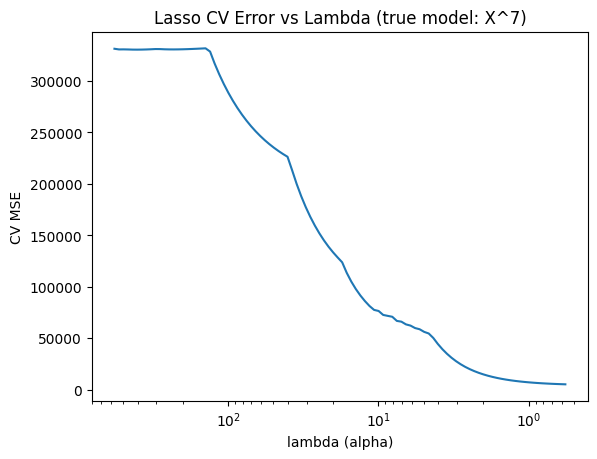

In [14]:
# Lasso on new data
X_poly2 = data2[predictors].values
y2 = data2['Y'].values

lasso_pipe2 = make_pipeline(
    StandardScaler(),
    LassoCV(cv=10, random_state=1)
)
lasso_pipe2.fit(X_poly2, y2)

lasso2 = lasso_pipe2.named_steps['lassocv']

print("=== (f) Lasso with CV (true model: X^7) ===")
print("Best alpha (lambda):", lasso2.alpha_)
print("Coefficients (standardized X):")
for name, coef in zip(predictors, lasso2.coef_):
    print(f"{name:>3s} : {coef: .4f}")
print()

# CV error vs λ for second scenario
mean_mse2 = lasso2.mse_path_.mean(axis=1)
alphas2 = lasso2.alphas_

plt.figure()
plt.plot(alphas2, mean_mse2)
plt.xscale('log')
plt.xlabel("lambda (alpha)")
plt.ylabel("CV MSE")
plt.title("Lasso CV Error vs Lambda (true model: X^7)")
plt.gca().invert_xaxis()
plt.show()